# Unsupervised Learning: Forest Fire Conditions

## TKH Capstone — Forest Fires

### Goal
Use an **unsupervised learning technique** to identify natural groups of forest-fire weather conditions.

For this project, we will use **K-Means clustering**.

The clustering results will be used in two ways:

1. To describe different types of fire-weather conditions in the dataset.
2. To create a `cluster` feature that can later be tested in the supervised regression model.




## 1. Import Libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

pd.set_option("display.max_columns", None)


## 2. Load the Processed Dataset

The processed dataset was created in `02_preprocessing.ipynb`.

The first path below is the path you should use when the notebook is stored inside your project's `notebooks/` folder.


In [5]:
project_path = Path("../data/processed/forestfires_processed.csv")
local_path = Path("/mnt/data/processed/forestfires_processed.csv")

if project_path.exists():
    data_path = project_path
elif local_path.exists():
    data_path = local_path
else:
    raise FileNotFoundError(
        "forestfires_processed.csv was not found. "
        "Place it in data/processed/ and rerun this cell."
    )

df = pd.read_csv(data_path)

print("Dataset shape:", df.shape)
df.head()


Dataset shape: (513, 31)


,X,Y,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area,log_area,month_apr,month_aug,month_dec,month_feb,month_jan,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,day_fri,day_mon,day_sat,day_sun,day_thu,day_tue,day_wed
0,7,5,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.0,0.0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0
1,7,4,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0
2,7,4,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.0,0.0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0
3,8,6,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.0,0.0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0
4,8,6,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.0,0.0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0


## 3. Select Features for Clustering

We want the clusters to represent **fire-weather conditions**, so we begin with the main meteorological variables and fire-weather indices:

- `FFMC` — Fine Fuel Moisture Code
- `DMC` — Duff Moisture Code
- `DC` — Drought Code
- `ISI` — Initial Spread Index
- `temp` — Temperature
- `RH` — Relative humidity
- `wind` — Wind speed
- `rain` — Rain

We will first inspect these variables before deciding on the final clustering feature set.

We do **not** include:
- `area` or `log_area` because they are supervised-model targets.
- Month/day dummy variables because the purpose here is to cluster observations based on environmental fire conditions.


In [6]:
candidate_features = [
    "FFMC", "DMC", "DC", "ISI",
    "temp", "RH", "wind", "rain"
]

df[candidate_features].describe().T


,count,mean,std,min,25%,50%,75%,max
FFMC,513.0,90.637427,5.540920,18.7,90.2,91.6,92.9,96.2
DMC,513.0,110.989279,64.191013,1.1,68.6,108.3,142.4,291.3
DC,513.0,549.155166,247.724594,7.9,440.9,664.5,713.9,860.6
ISI,513.0,9.023587,4.575543,0.0,6.4,8.4,11.0,56.1
temp,513.0,18.887524,5.828128,2.2,15.5,19.3,22.8,33.3
RH,513.0,44.348928,16.358803,15.0,33.0,42.0,53.0,100.0
wind,513.0,4.010526,1.796613,0.4,2.7,4.0,4.9,9.4
rain,513.0,0.021832,0.297107,0.0,0.0,0.0,0.0,6.4


## 4. Check Whether Any Feature Could Distort the Clustering

K-Means uses distances between observations. A variable with an unusual distribution or extreme sparsity can strongly influence those distances.

Let's inspect how often rain actually occurs.


In [7]:
print(df["rain"].value_counts().sort_index())
print()
print(f"Rows with zero rain: {(df['rain'] == 0).sum()} of {len(df)}")
print(f"Percent with zero rain: {(df['rain'] == 0).mean() * 100:.1f}%")


rain
0.0    505
0.2      2
0.4      1
0.8      2
1.0      1
1.4      1
6.4      1
Name: count, dtype: int64

Rows with zero rain: 505 of 513
Percent with zero rain: 98.4%


### Decision: Exclude `rain` from the final K-Means model

`rain` is zero for almost the entire dataset. Because StandardScaler gives rare non-zero rain values large standardized distances, including rain causes K-Means solutions with **tiny or one-observation clusters**.

That would make the clusters less useful for describing general fire-weather patterns.

Therefore, the final clustering features are:


In [8]:
cluster_features = [
    "FFMC", "DMC", "DC", "ISI",
    "temp", "RH", "wind"
]

X_cluster = df[cluster_features].copy()

print("Features used for clustering:")
print(cluster_features)
print()
print("Clustering matrix shape:", X_cluster.shape)


Features used for clustering:
['FFMC', 'DMC', 'DC', 'ISI', 'temp', 'RH', 'wind']

Clustering matrix shape: (513, 7)


## 5. Scale the Clustering Features

K-Means is distance-based, so variables measured on larger numerical scales would otherwise dominate the algorithm.

We standardize each clustering variable to approximately:

- Mean = 0
- Standard deviation = 1

The scaler is fitted **only to the variables used for clustering**.


In [9]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=cluster_features,
    index=df.index
)

X_scaled_df.head()


,FFMC,DMC,DC,ISI,temp,RH,wind
0,-0.801628,-1.322179,-1.837925,-0.858350,-1.835573,0.406971,1.498430
1,-0.006761,-1.178717,0.484659,-0.508323,-0.152432,-0.694428,-1.733018
2,-0.006761,-1.049290,0.556583,-0.508323,-0.736379,-0.694428,-1.510159
3,0.191956,-1.211464,-1.905808,-0.005160,-1.818399,3.221658,-0.005865
4,-0.241608,-0.930777,-1.806003,0.126100,-1.285976,3.344035,-1.231586


## 6. Determine the Number of Clusters

We will compare **K = 2 through K = 6** using two methods:

### Elbow Method
Measures within-cluster variation (`inertia`). Lower inertia is better, but we look for a point where the improvement begins to level off.

### Silhouette Score
Measures how well observations fit within their assigned cluster compared with neighboring clusters.

- Closer to **1** = better-defined clusters
- Around **0** = overlapping clusters
- Negative = observations may be assigned poorly

We will use both measures rather than selecting K arbitrarily.


In [10]:
k_values = range(2, 7)

inertias = []
silhouette_scores = []

for k in k_values:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_scaled)

    inertias.append(model.inertia_)
    silhouette_scores.append(
        silhouette_score(X_scaled, labels)
    )

cluster_evaluation = pd.DataFrame({
    "k": list(k_values),
    "inertia": inertias,
    "silhouette_score": silhouette_scores
})

cluster_evaluation


,k,inertia,silhouette_score
0,2,2538.579872,0.375808
1,3,2183.654920,0.243943
2,4,1932.053182,0.259074
3,5,1732.406590,0.223844
4,6,1563.613967,0.208132


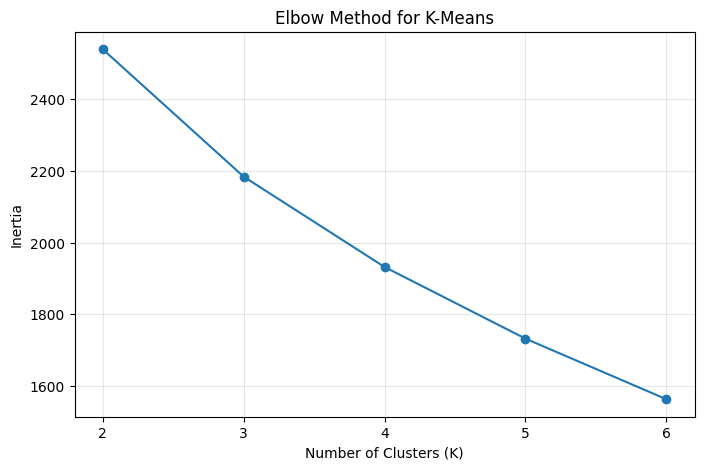

In [11]:
plt.figure(figsize=(8, 5))
plt.plot(
    cluster_evaluation["k"],
    cluster_evaluation["inertia"],
    marker="o"
)
plt.title("Elbow Method for K-Means")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.xticks(cluster_evaluation["k"])
plt.grid(alpha=0.3)
plt.show()


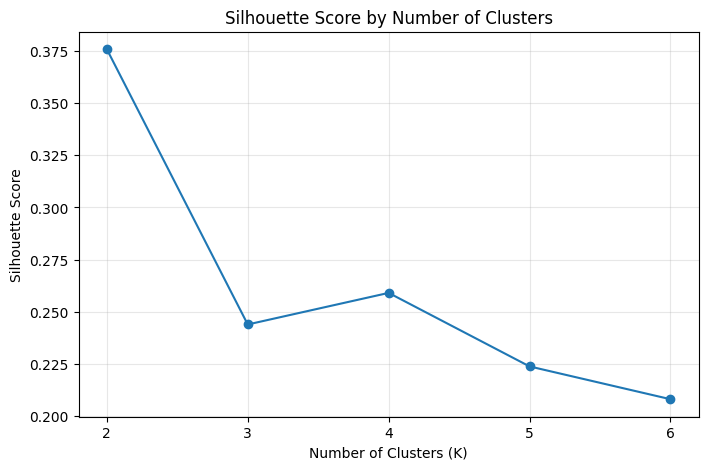

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(
    cluster_evaluation["k"],
    cluster_evaluation["silhouette_score"],
    marker="o"
)
plt.title("Silhouette Score by Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.xticks(cluster_evaluation["k"])
plt.grid(alpha=0.3)
plt.show()


In [13]:
best_k = cluster_evaluation.loc[
    cluster_evaluation["silhouette_score"].idxmax(),
    "k"
]

best_score = cluster_evaluation["silhouette_score"].max()

print(f"Highest silhouette score: {best_score:.3f}")
print(f"Best K based on silhouette score: {int(best_k)}")


Highest silhouette score: 0.376
Best K based on silhouette score: 2


## 7. Fit the Final K-Means Model

For this dataset, **K = 2** provides the strongest silhouette score among the tested cluster counts and produces meaningful cluster sizes.

We therefore use two clusters for the final unsupervised analysis.


In [14]:
final_k = 2

kmeans = KMeans(
    n_clusters=final_k,
    random_state=42,
    n_init=10
)

df["cluster"] = kmeans.fit_predict(X_scaled)

df["cluster"].value_counts().sort_index()


cluster
0    395
1    118
Name: count, dtype: int64

## 8. Examine Cluster Sizes

Before interpreting the clusters, make sure neither cluster contains only a tiny number of observations.


In [15]:
cluster_counts = (
    df["cluster"]
    .value_counts()
    .sort_index()
    .rename("count")
    .to_frame()
)

cluster_counts["percent"] = (
    cluster_counts["count"] / len(df) * 100
).round(1)

cluster_counts


,count,percent
cluster,,
0,395,77.0
1,118,23.0


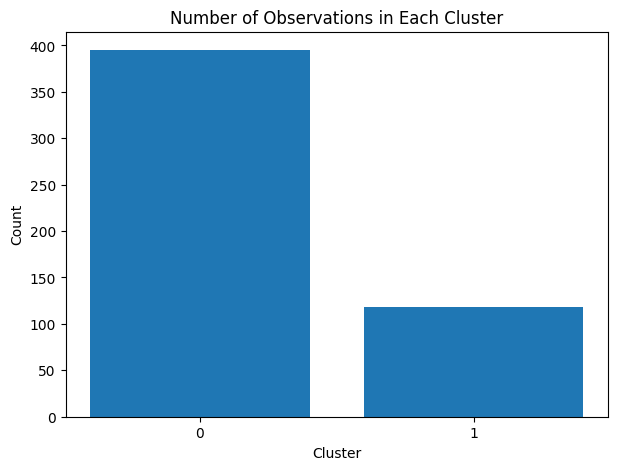

In [16]:
cluster_counts_plot = df["cluster"].value_counts().sort_index()

plt.figure(figsize=(7, 5))
plt.bar(
    cluster_counts_plot.index.astype(str),
    cluster_counts_plot.values
)
plt.title("Number of Observations in Each Cluster")
plt.xlabel("Cluster")
plt.ylabel("Count")
plt.show()


## 9. Profile the Clusters

Now we compare the average fire-weather conditions in each cluster.

This helps translate cluster numbers into understandable environmental patterns.


In [17]:
cluster_profile = (
    df.groupby("cluster")[cluster_features]
    .mean()
    .round(2)
)

cluster_profile


,FFMC,DMC,DC,ISI,temp,RH,wind
cluster,,,,,,,
0,92.14,133.91,664.65,10.07,20.88,43.18,3.76
1,85.60,34.27,162.53,5.54,12.23,48.25,4.86


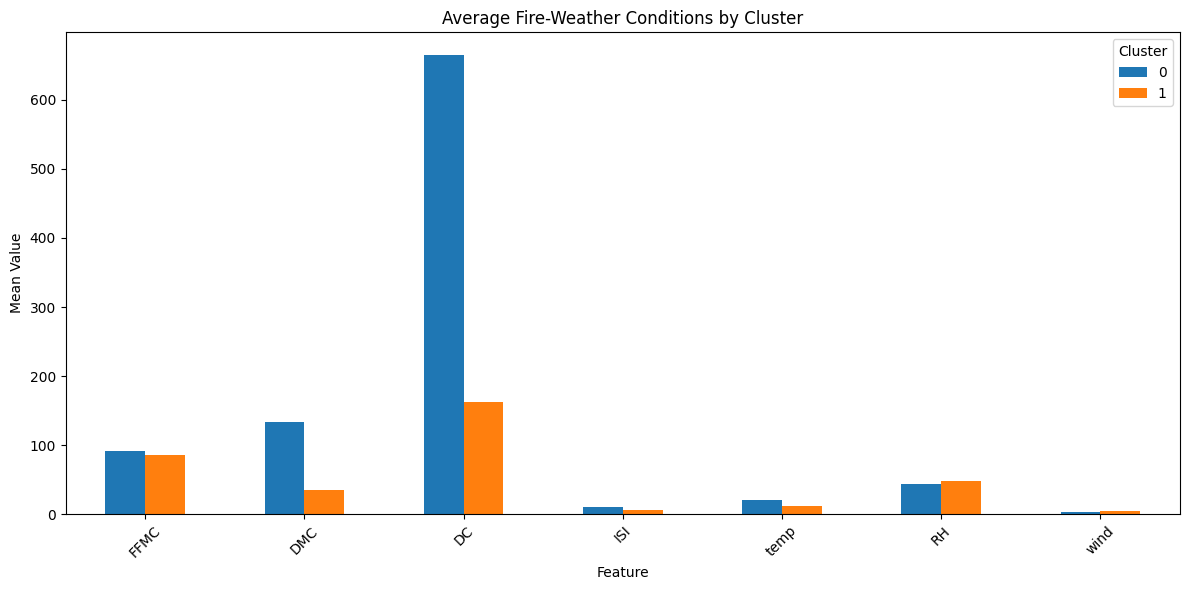

In [18]:
cluster_profile.T.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Average Fire-Weather Conditions by Cluster")
plt.xlabel("Feature")
plt.ylabel("Mean Value")
plt.xticks(rotation=45)
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()


### Interpreting the two clusters

The cluster profile should show a clear contrast:

- **Cluster 0** generally represents **hotter, drier, higher fire-danger conditions**, with higher FFMC, DMC, DC, ISI, and temperature.
- **Cluster 1** generally represents **cooler / less dry conditions**, with lower fire-weather index values and somewhat higher relative humidity and wind.

The labels `0` and `1` have no inherent meaning; they are simply identifiers assigned by K-Means.


## 10. Compare Clusters With Burned Area

`area` and `log_area` were deliberately excluded from clustering.

Now that the groups have been created independently, we can compare their burned-area outcomes to see whether the environmental clusters provide a useful segmentation lens.


In [19]:
cluster_area_summary = (
    df.groupby("cluster")
    .agg(
        observations=("area", "size"),
        mean_area=("area", "mean"),
        median_area=("area", "median"),
        mean_log_area=("log_area", "mean"),
        median_log_area=("log_area", "median")
    )
    .round(2)
)

cluster_area_summary


,observations,mean_area,median_area,mean_log_area,median_log_area
cluster,,,,,
0,395,14.97,0.76,1.15,0.57
1,118,5.94,0.00,0.99,0.00


/var/folders/w4/gdzwlf5x4bb1bcpny3dj6jhw0000gn/T/ipykernel_74808/24514044.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


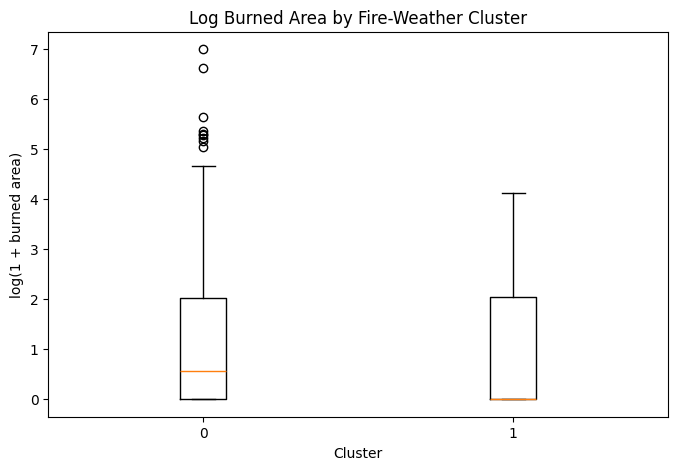

In [20]:
boxplot_data = [
    df.loc[df["cluster"] == cluster, "log_area"]
    for cluster in sorted(df["cluster"].unique())
]

plt.figure(figsize=(8, 5))
plt.boxplot(
    boxplot_data,
    labels=[str(c) for c in sorted(df["cluster"].unique())]
)
plt.title("Log Burned Area by Fire-Weather Cluster")
plt.xlabel("Cluster")
plt.ylabel("log(1 + burned area)")
plt.show()


### Interpretation

The hotter/drier cluster has a higher average burned area in this dataset, but the distributions still overlap substantially.

That is an important result:

> **Weather-condition clusters appear to provide useful context, but they do not completely explain fire size.**

This supports using the cluster assignment as an **additional feature or segmentation variable** in the supervised model rather than treating it as a complete predictor by itself.


## 11. Visualize the Clusters With PCA

Because the clustering uses seven variables, we cannot directly plot all dimensions at once.

We use **Principal Component Analysis (PCA)** to project the standardized observations into two dimensions for visualization.

PCA here is used only to **visualize** the K-Means solution.  
The K-Means model itself was trained using all seven standardized fire-weather variables.


In [21]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "cluster": df["cluster"].values
})

explained_variance = pca.explained_variance_ratio_

print(
    f"PC1 explained variance: {explained_variance[0]:.1%}"
)
print(
    f"PC2 explained variance: {explained_variance[1]:.1%}"
)
print(
    f"Combined explained variance: {explained_variance.sum():.1%}"
)


PC1 explained variance: 40.6%
PC2 explained variance: 18.3%
Combined explained variance: 58.9%


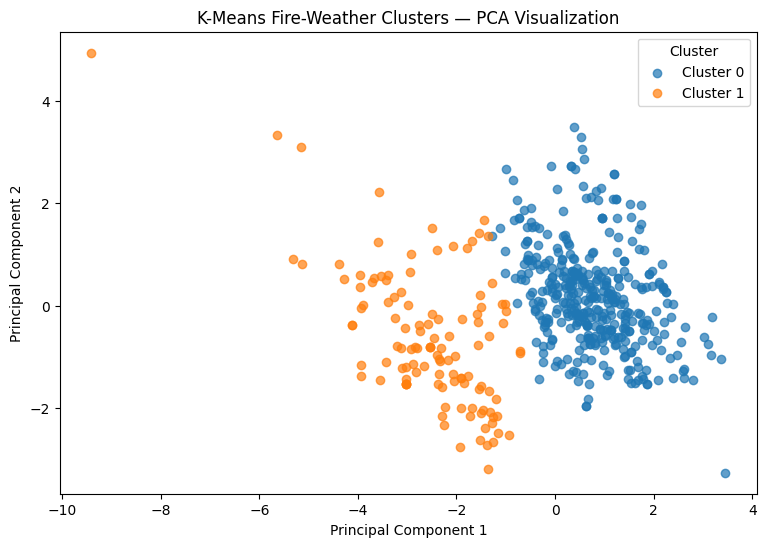

In [22]:
plt.figure(figsize=(9, 6))

for cluster in sorted(pca_df["cluster"].unique()):
    subset = pca_df[pca_df["cluster"] == cluster]
    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        alpha=0.7,
        label=f"Cluster {cluster}"
    )

plt.title("K-Means Fire-Weather Clusters — PCA Visualization")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.show()


## 12. Optional: Inspect PCA Loadings

PCA loadings help us understand which original variables contribute most to the two visualization axes.


In [23]:
pca_loadings = pd.DataFrame(
    pca.components_.T,
    index=cluster_features,
    columns=["PC1", "PC2"]
)

pca_loadings.round(3)


,PC1,PC2
FFMC,0.428,-0.224
DMC,0.432,0.457
DC,0.434,0.427
ISI,0.363,-0.220
temp,0.488,-0.171
RH,-0.235,0.653
wind,-0.128,-0.233


## 13. Add Cluster Labels to the Processed Dataset

The capstone requirement asks us to use the unsupervised results to inform the supervised modeling.

We will therefore save the cluster assignment as a new column.

The next supervised-learning notebook can test whether adding `cluster` improves prediction of `log_area`.


In [24]:
output_project_path = Path("../data/processed/forestfires_with_clusters.csv")
fallback_path = Path("/mnt/data/forestfires_with_clusters.csv")

try:
    output_project_path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(output_project_path, index=False)
    output_path = output_project_path
except (PermissionError, OSError):
    df.to_csv(fallback_path, index=False)
    output_path = fallback_path

print(f"Saved clustered dataset to: {output_path}")
print("Final dataset shape:", df.shape)


Saved clustered dataset to: ../data/processed/forestfires_with_clusters.csv
Final dataset shape: (513, 32)


## 14. Key Unsupervised-Learning Findings

### What we did
- Selected fire-weather variables for unsupervised analysis.
- Standardized the features before applying K-Means.
- Tested cluster counts from **K = 2 to K = 6**.
- Compared solutions using the **elbow method** and **silhouette score**.
- Selected a **2-cluster solution**.
- Used PCA to visualize the high-dimensional cluster structure.
- Compared the resulting groups with burned area only after clustering.
- Added the cluster assignment to the processed dataset for supervised modeling.

### Main findings
1. The dataset separates into two broad environmental-condition groups.
2. One cluster represents generally **hotter, drier, higher fire-danger conditions**.
3. The other represents generally **cooler / less dry conditions**.
4. Burned-area outcomes differ somewhat between the clusters, but there is substantial overlap.
5. Therefore, the cluster label may provide useful additional information, but it should not be expected to predict burned area on its own.

### Connection to the supervised model
The next notebook will predict `log_area` using regression models.

We can compare:

- **Model without the cluster feature**
- **Model with the cluster feature**

This directly demonstrates how the unsupervised-learning step informed the supervised-learning stage of the TKH capstone.
